# Mon Sandbox

Notebook pour tester du script afin d'alimenter la base de données :p

### test sur inaturalist

In [12]:
import requests
import json

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Paramètres mis à jour
params = {
    "taxon_id": "47219,52747",  
    "per_page": 10,              
    "page": 1                 
}


response = requests.get(url, params=params)


if response.status_code == 200:
    data = response.json()
    observations = data.get("results", [])

    # test sur 3 results, afin d'observer la structure
    print(json.dumps(observations[:3], indent=4, ensure_ascii=False))

else:
    print(f"Erreur {response.status_code}: Impossible d’accéder aux observations.")


[
    {
        "quality_grade": "needs_id",
        "time_observed_at": "2024-08-11T13:24:30-04:00",
        "taxon_geoprivacy": null,
        "annotations": [],
        "uuid": "45ef2ef2-a40b-431c-a275-ab8b94ed3540",
        "observed_on_details": {
            "date": "2024-08-11",
            "day": 11,
            "month": 8,
            "year": 2024,
            "hour": 13,
            "week": 32
        },
        "id": 259928641,
        "cached_votes_total": 0,
        "identifications_most_agree": false,
        "created_at_details": {
            "date": "2025-01-28",
            "day": 28,
            "month": 1,
            "year": 2025,
            "hour": 22,
            "week": 5
        },
        "species_guess": null,
        "identifications_most_disagree": false,
        "tags": [],
        "positional_accuracy": 10,
        "comments_count": 0,
        "site_id": 1,
        "created_time_zone": "America/New_York",
        "license_code": "cc-by-nc",
        "obser

In [13]:
import requests

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Paramètres mis à jour
# taxon : # Apidae (abeilles) et Vespidae (frelons)
params = {
    "taxon_id": "47219,52747",  
    "per_page": 10,              
    "page": 1                    
}

# Effectuer la requête
response = requests.get(url, params=params)


if response.status_code == 200:
    data = response.json()
    observations = data.get("results", [])

  
    if not observations:
        print("Aucune observation trouvée avec ces paramètres.")
    else:
        # Afficher les résultats
        for obs in observations:
            id_obs = obs.get("id", "Inconnu")
            nom = obs.get("species_guess", "Nom inconnu")
            date = obs.get("observed_on", "Date inconnue")
            latitude = obs.get("latitude", "Inconnue")
            longitude = obs.get("longitude", "Inconnue")
            lien = f"https://www.inaturalist.org/observations/{id_obs}"

            print(f"ID: {id_obs}, Nom: {nom}, Date: {date}, Lien: {lien}, Localisation: ({latitude}, {longitude})")

else:
    print(f"Erreur {response.status_code}: Impossible d’accéder aux observations.")


ID: 259928641, Nom: None, Date: 2024-08-11, Lien: https://www.inaturalist.org/observations/259928641, Localisation: (Inconnue, Inconnue)
ID: 259928497, Nom: Frelons, Date: 2025-01-25, Lien: https://www.inaturalist.org/observations/259928497, Localisation: (Inconnue, Inconnue)
ID: 259928423, Nom: None, Date: 2025-01-28, Lien: https://www.inaturalist.org/observations/259928423, Localisation: (Inconnue, Inconnue)
ID: 259928023, Nom: Western Honey Bee, Date: 2025-01-28, Lien: https://www.inaturalist.org/observations/259928023, Localisation: (Inconnue, Inconnue)
ID: 259928011, Nom: Western Honey Bee, Date: 2025-01-28, Lien: https://www.inaturalist.org/observations/259928011, Localisation: (Inconnue, Inconnue)
ID: 259927806, Nom: Feldwespen, Date: 2025-01-28, Lien: https://www.inaturalist.org/observations/259927806, Localisation: (Inconnue, Inconnue)
ID: 259927418, Nom: None, Date: 2025-01-29, Lien: https://www.inaturalist.org/observations/259927418, Localisation: (Inconnue, Inconnue)
ID: 25

In [1]:
import requests
import json

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Paramètres de la requête API
params = {
    "taxon_id": "47219,52747",  # Apidae (abeilles) et Vespidae (frelons)
    "per_page": 10,              # Nombre d'observations par page
    "page": 1,                   # Première page des résultats
    "order_by": "observed_on",    # Trier par date d'observation
}

# Effectuer la requête
response = requests.get(url, params=params)

# Vérifier si la requête a réussi
if response.status_code == 200:
    data = response.json()
    observations = data.get("results", [])

    # Vérifier si des résultats existent
    if not observations:
        print("Aucune observation trouvée avec ces paramètres.")
    else:
        # Afficher les résultats
        for obs in observations:
            id_obs = obs.get("id", "Inconnu")
            nom = obs.get("species_guess", "Nom inconnu")
            date = obs.get("observed_on", "Date inconnue")
            latitude = obs.get("latitude", "Inconnue")
            longitude = obs.get("longitude", "Inconnue")
            place = obs.get("place_guess", "Lieu inconnu")
            user = obs.get("user", {}).get("login", "Utilisateur inconnu")
            image = obs.get("photos", [{}])[0].get("url", "Aucune image")
            quality = obs.get("quality_grade", "Inconnu")  # 'research', 'needs_id', 'casual'
            identifications = obs.get("identifications_count", 0)  # Nombre de vérifications par d'autres utilisateurs
            lien = f"https://www.inaturalist.org/observations/{id_obs}"

            # Affichage structuré
            print(f"🔹 **Observation ID:** {id_obs}")
            print(f"👤 **Utilisateur:** {user}")
            print(f"📅 **Date:** {date}")
            print(f"📍 **Lieu:** {place}")
            print(f"🌍 **Coordonnées:** ({latitude}, {longitude})")
            print(f"📸 **Image:** {image}")
            print(f"🔍 **Qualité des données:** {quality}")
            print(f"📊 **Nombre d'identifications:** {identifications}")
            print(f"🔗 **Lien:** {lien}")
            print("-" * 80)

else:
    print(f"Erreur {response.status_code}: Impossible d’accéder aux observations.")


🔹 **Observation ID:** 260528945
👤 **Utilisateur:** geospyder
📅 **Date:** 2025-02-03
📍 **Lieu:** Cedar Ridge Dr, China Spring, TX, US
🌍 **Coordonnées:** (Inconnue, Inconnue)
📸 **Image:** https://inaturalist-open-data.s3.amazonaws.com/photos/467886918/square.jpg
🔍 **Qualité des données:** needs_id
📊 **Nombre d'identifications:** 0
🔗 **Lien:** https://www.inaturalist.org/observations/260528945
--------------------------------------------------------------------------------
🔹 **Observation ID:** 260528630
👤 **Utilisateur:** shadowsmom21666
📅 **Date:** 2025-02-03
📍 **Lieu:** E Sonterra Blvd, San Antonio, TX, US
🌍 **Coordonnées:** (Inconnue, Inconnue)
📸 **Image:** https://inaturalist-open-data.s3.amazonaws.com/photos/467886198/square.jpg
🔍 **Qualité des données:** needs_id
📊 **Nombre d'identifications:** 0
🔗 **Lien:** https://www.inaturalist.org/observations/260528630
--------------------------------------------------------------------------------
🔹 **Observation ID:** 260528474
👤 **Utilisat

#### Remarque

Aucune données localisation précise au sein de l'api > pour y remédier passer par les liens d'observations

Abeilles :

Abeille domestique (Apis mellifera) : 47218

Famille des Apidés (incluant de nombreuses espèces d'abeilles) : 47219


Guêpes :


Famille des Vespidés (incluant de nombreuses espèces de guêpes) : 52747


Frelons :

Frelon asiatique (Vespa velutina) : 52750

Frelon européen (Vespa crabro) : 52749

In [ ]:
import requests
import json
import datetime
import time
import os

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Définir les taxons (abeilles, guêpes, frelons, ruches)
taxon_ids = "630955,630956,538877,538878,52747,47218"  

# Définir une date de départ
d1 = "2023-01-01"  

# Fichiers pour sauvegarder les données
OBSERVATIONS_FILE = "observations.json"
EXTRACTED_FILE = "extracted_data.json"

# Charger les observations précédemment enregistrées si le fichier existe
if os.path.exists(OBSERVATIONS_FILE):
    with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
        all_observations = json.load(f)
        print(f"📂 Chargement de {len(all_observations)} observations depuis {OBSERVATIONS_FILE}.")
else:
    all_observations = []

page = (len(all_observations) // 100) + 1  # Déterminer la page où continuer

while True:
    print(f"🔄 Récupération de la page {page}...")

    # Paramètres de la requête
    params = {
        "taxon_id": taxon_ids,  # Abeilles, guêpes, frelons, ruches
        "per_page": 100,  # Maximiser à 100 pour optimiser les requêtes
        "page": page,  # Pagination
        "order_by": "observed_on",  # Trier par date d'observation
        "order": "asc",  # Chronologique
        "d1": d1,  # Date de début
        "geoprivacy": "open",  # Données ouvertes
        "place_id": 6753  # Modifier selon la région
    }

    # Requête API
    response = requests.get(url, params=params)

    # Vérifier si la requête est un succès
    if response.status_code == 200:
        data = response.json()
        observations = data.get("results", [])

        if not observations:
            print("✅ Fin de récupération (plus d'observations à récupérer).")
            break  # Arrêter si plus de résultats

        # Ajouter les observations à la liste
        all_observations.extend(observations)
        print(f"📊 {len(all_observations)} observations récupérées.")

        # Sauvegarder les observations après chaque requête
        with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
            json.dump(all_observations, f, ensure_ascii=False, indent=4)
            print(f"💾 Données sauvegardées dans {OBSERVATIONS_FILE}.")

        page += 1  # Passer à la page suivante

        # Petite pause pour éviter le rate limit de l'API
        time.sleep(1)

    else:
        print(f"❌ Erreur {response.status_code}: Impossible de récupérer les données.")
        break  # Arrêter en cas d'erreur

# 🔹 Trier les observations en ordre chronologique (normalement déjà triées)
all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

# Charger les données extraites précédemment enregistrées
if os.path.exists(EXTRACTED_FILE):
    with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
        extracted_data = json.load(f)
        print(f"📂 Chargement de {len(extracted_data)} extractions depuis {EXTRACTED_FILE}.")
else:
    extracted_data = []

# 🔹 **Extraction des données**
for i, obs in enumerate(all_observations):

    id_obs = obs.get("id", "Unknown")
    date = obs.get("observed_on", "Unknown Date")
    place = obs.get("place_guess", "Unknown Place")

    # Extract Taxon Data
    taxon = obs.get("taxon", {})
    scientific_name = taxon.get("name", "Unknown Scientific Name")
    common_name = taxon.get("preferred_common_name", "Unknown Common Name")
    observation_link = obs.get("uri", f"https://www.inaturalist.org/observations/{id_obs}")

    # Stocker dans extracted_data
    extracted_data.append({
        "ID": id_obs,
        "Scientific Name": scientific_name,
        "Common Name": common_name,
        "Date": date,
        "Place": place,
        "Observation Link": observation_link
    })

    # Sauvegarder après chaque 200 extractions (optimisation des écritures disque)


In [7]:
import requests
import json
import datetime
import time
import os

# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Définir les taxons (abeilles, guêpes, frelons, ruches)
taxon_ids = "630955,630956,538877,538878,52747,47218"  

# Définir une date de départ
d1 = "2024-11-31"  

OBSERVATIONS_FILE = os.path.join(os.getcwd(), "observations.json")
EXTRACTED_FILE = os.path.join(os.getcwd(), "extracted_data.json")

# Charger les observations précédemment enregistrées si le fichier existe
if os.path.exists(OBSERVATIONS_FILE):
    with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
        all_observations = json.load(f)
        print(f"📂 Chargement de {len(all_observations)} observations depuis {OBSERVATIONS_FILE}.")
else:
    all_observations = []

page = (len(all_observations) // 100) + 1  # Déterminer la page où continuer

while True:
    print(f"🔄 Récupération de la page {page}...")

    # Paramètres de la requête
    params = {
        "taxon_id": taxon_ids,
        "per_page": 100,  
        "page": page,  
        "order_by": "observed_on",
        "order": "asc",  
        "d1": d1,  
        "geoprivacy": "open",
        "place_id": 6753  
    }

    # Requête API
    response = requests.get(url, params=params)

    # Vérifier si la requête est un succès
    if response.status_code == 200:
        data = response.json()
        observations = data.get("results", [])

        if not observations:
            print("✅ Fin de récupération (plus d'observations à récupérer).")
            break  

        # Ajouter les observations à la liste
        all_observations.extend(observations)
        print(f"📊 {len(all_observations)} observations récupérées.")
        # Sauvegarder les observations après chaque requête
        with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
            json.dump(all_observations, f, ensure_ascii=False, indent=4)
            print(f"💾 Données sauvegardées dans {OBSERVATIONS_FILE}.")

        page += 1  

        # Petite pause pour éviter le rate limit de l'API
        time.sleep(1)

    else:
        print(f"❌ Erreur {response.status_code}: Impossible de récupérer les données.")
        break  

# 🔹 Trier les observations en ordre chronologique
all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

# Charger les données extraites précédemment enregistrées
if os.path.exists(EXTRACTED_FILE):
    with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
        extracted_data = json.load(f)
        print(f"📂 Chargement de {len(extracted_data)} extractions depuis {EXTRACTED_FILE}.")
else:
    extracted_data = []

# 🔹 **Extraction des données**
for i, obs in enumerate(all_observations):

    id_obs = obs.get("id", "Unknown")
    date = obs.get("observed_on", "Unknown Date")
    time_zone = obs.get("observed_time_zone", "Unknown Timezone")
    positional_accuracy = obs.get("positional_accuracy", "Unknown")
    public_accuracy = obs.get("public_positional_accuracy", "Unknown")
    geoprivacy = obs.get("geoprivacy", "Unknown")
    quality_grade = obs.get("quality_grade", "Unknown") 
    identifications_count = obs.get("identifications_count", 0)
    num_agreements = obs.get("num_identification_agreements", 0)
    num_disagreements = obs.get("num_identification_disagreements", 0)

    # 🔹 **Extract Coordinates**
    longitude, latitude = None, None
    geojson = obs.get("geojson")
    if geojson and isinstance(geojson, dict) and "coordinates" in geojson:
        coordinates = geojson["coordinates"]
        if isinstance(coordinates, list) and len(coordinates) == 2:
            longitude, latitude = coordinates  

    if not longitude or not latitude:
        location = obs.get("location")
        if location and isinstance(location, str):
            try:
                lat, lon = map(float, location.split(","))
                latitude, longitude = lat, lon
            except ValueError:
                pass  

    # Extract place information
    place = obs.get("place_guess", "Unknown Place")

    # Extract Taxon Data
    taxon = obs.get("taxon", {})
    scientific_name = taxon.get("name", "Unknown Scientific Name")
    common_name = taxon.get("preferred_common_name", "Unknown Common Name")
    taxon_rank = taxon.get("rank", "Unknown Rank")
    taxon_id = taxon.get("id", "Unknown")
    wiki_url = taxon.get("wikipedia_url", "No Wikipedia Link")

    # Extract User Data
    user = obs.get("user", {})
    user_login = user.get("login", "Unknown User")
    user_observations = user.get("observations_count", 0)
    user_identifications = user.get("identifications_count", 0)
    user_icon = user.get("icon_url", "No User Image")

    # Extract Media
    photos = obs.get("photos", [])
    image_url = photos[0]["url"] if photos else "No Image"

    # Extract Annotations, Comments, and Tags
    annotations = [a.get("concatenated_attr_val", "No Annotation") for a in obs.get("annotations", [])]
    comments = obs.get("comments_count", 0)
    tags = ", ".join(obs.get("tags", ["No Tags"]))

    # Extract Extra Metadata
    uuid = obs.get("uuid", "Unknown")
    description = obs.get("description", "No Description")
    votes = obs.get("cached_votes_total", 0)
    observation_link = obs.get("uri", f"https://www.inaturalist.org/observations/{id_obs}")

    # Stocker dans extracted_data
    extracted_data.append({
        "ID": id_obs,
        "Scientific Name": scientific_name,
        "Common Name": common_name,
        "Taxon Rank": taxon_rank,
        "Taxon ID": taxon_id,
        "Wikipedia Link": wiki_url,
        "User": user_login,
        "User Observations": user_observations,
        "User Identifications": user_identifications,
        "User Icon": user_icon,
        "Date": date,
        "Time Zone": time_zone,
        "Latitude": latitude,
        "Longitude": longitude,
        "Place": place,
        "Positional Accuracy": positional_accuracy,
        "Public Accuracy": public_accuracy,
        "Geoprivacy": geoprivacy,
        "Quality Grade": quality_grade,
        "Identifications Count": identifications_count,
        "Agreements": num_agreements,
        "Disagreements": num_disagreements,
        "Image": image_url,
        "Annotations": annotations,
        "Comments Count": comments,
        "Tags": tags,
        "Votes": votes,
        "UUID": uuid,
        "Description": description,
        "Observation Link": observation_link
    })

# Sauvegarde finale
with open(EXTRACTED_FILE, "w", encoding="utf-8") as f:
    json.dump(extracted_data, f, ensure_ascii=False, indent=4)
    print(f"✅ Extraction complète. Total: {len(extracted_data)} observations extraites sauvegardées.")



📂 Chargement de 2500 observations depuis c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations.json.
🔄 Récupération de la page 26...
📊 2600 observations récupérées.
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations.json.
🔄 Récupération de la page 27...
📊 2700 observations récupérées.
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations.json.
🔄 Récupération de la page 28...
📊 2800 observations récupérées.
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations.json.
🔄 Récupération de la page 29...
📊 2900 observations récupérées.
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations.json.
🔄 Récupération de la page 30...
📊 3000 observations récupérées.
💾 Données sauvegardées dans c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observat

### Observation extraction

🔍 Aperçu des premières lignes :
          ID        Scientific Name             Common Name Taxon Rank  \
0  145577998           Vespa crabro         European Hornet    species   
1  145570252         Vespa velutina    Yellow-legged Hornet    species   
2  145568840              Eumeninae  Potter and Mason Wasps  subfamily   
3  145587919  Asparagus acutifolius         Spiny Asparagus    species   
4  145571792      Galanthus nivalis         common snowdrop    species   

   Taxon ID                                     Wikipedia Link  \
0     54327       http://en.wikipedia.org/wiki/European_hornet   
1    119019          http://en.wikipedia.org/wiki/Asian_hornet   
2    119344           http://en.wikipedia.org/wiki/Potter_wasp   
3    210513  http://en.wikipedia.org/wiki/Asparagus_acutifo...   
4     51606     http://en.wikipedia.org/wiki/Galanthus_nivalis   

             User  User Observations  User Identifications  \
0  baptiste_lecoq                678                    36   
1 

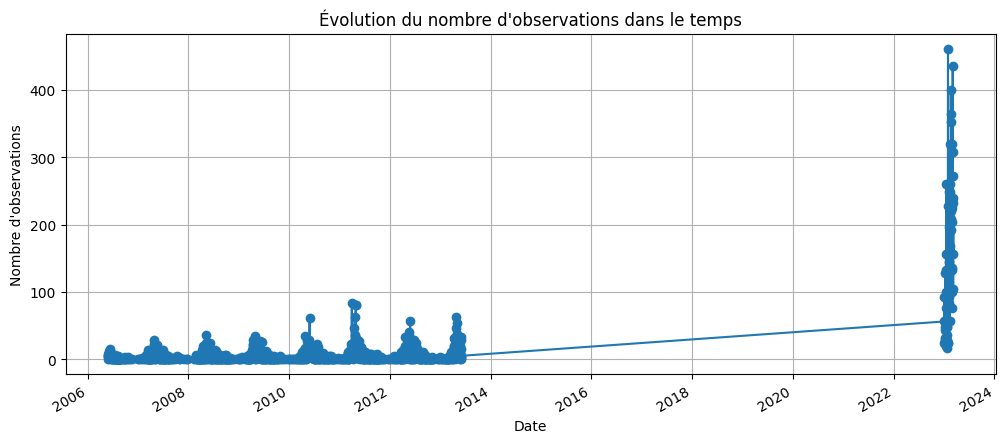

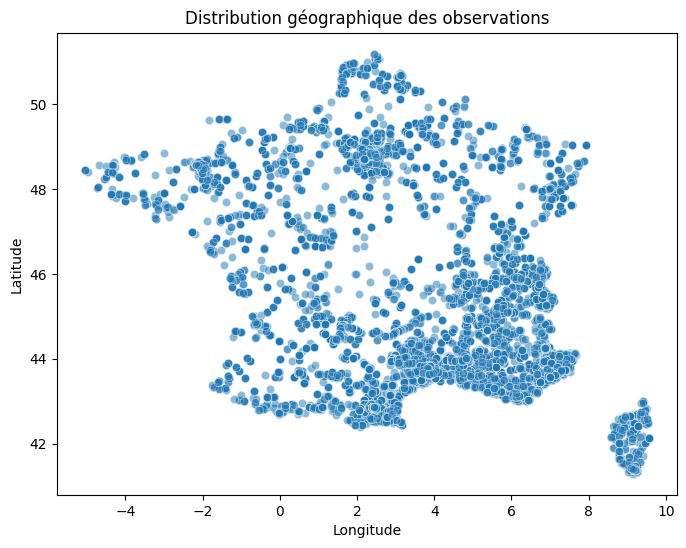

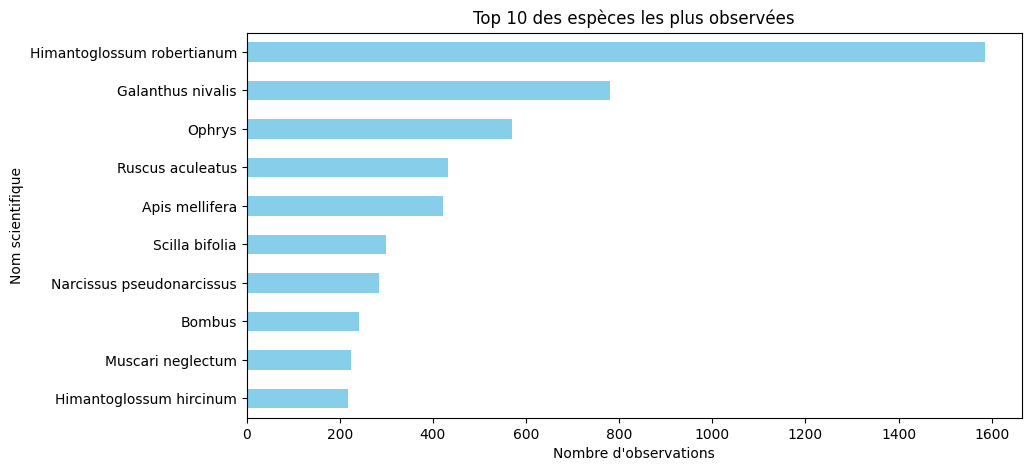

✅ Analyse terminée !


In [8]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 📂 Charger les données depuis le fichier JSON
EXTRACTED_FILE = "extracted_data.json"

if not os.path.exists(EXTRACTED_FILE):
    print(f"❌ Le fichier {EXTRACTED_FILE} n'existe pas.")
    exit()

with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
    extracted_data = json.load(f)

# 📊 Convertir en DataFrame Pandas
df = pd.DataFrame(extracted_data)

# 🔹 Vérifier la structure des données
print("🔍 Aperçu des premières lignes :")
print(df.head())

print("\n📊 Informations générales sur les données :")
print(df.info())

print("\n🔍 Nombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

# 🔹 Statistiques descriptives pour les colonnes numériques
print("\n📈 Statistiques descriptives :")
print(df.describe())

# 🔹 Compter les observations par taxon
print("\n🦠 Répartition des espèces observées :")
print(df["Scientific Name"].value_counts().head(10))  # Top 10 des espèces

# 🔹 Compter les observations par utilisateur
print("\n👤 Top 10 des utilisateurs ayant le plus d'observations :")
print(df["User"].value_counts().head(10))

# 🔹 Compter les observations par qualité
print("\n🔍 Qualité des observations :")
print(df["Quality Grade"].value_counts())

# 🔹 Vérifier les doublons
duplicates = df[df.duplicated(subset=["ID"], keep=False)]
print(f"\n⚠️ Nombre de doublons dans les observations : {len(duplicates)}")

# 🔹 Vérifier les valeurs aberrantes des coordonnées
invalid_locations = df[(df["Latitude"] < -90) | (df["Latitude"] > 90) | (df["Longitude"] < -180) | (df["Longitude"] > 180)]
print(f"\n⚠️ Nombre d'observations avec des coordonnées invalides : {len(invalid_locations)}")

# 📅 🔹 Analyser la répartition des observations par date
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])  # Supprimer les lignes où la date est invalide

plt.figure(figsize=(12, 5))
df["Date"].value_counts().sort_index().plot(kind="line", marker="o")
plt.title("Évolution du nombre d'observations dans le temps")
plt.xlabel("Date")
plt.ylabel("Nombre d'observations")
plt.grid()
plt.show()

# 🌍 🔹 Visualisation de la répartition géographique des observations
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df["Longitude"], y=df["Latitude"], alpha=0.5)
plt.title("Distribution géographique des observations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# 🦠 🔹 Visualisation des espèces les plus observées
plt.figure(figsize=(10, 5))
df["Scientific Name"].value_counts().head(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 des espèces les plus observées")
plt.xlabel("Nombre d'observations")
plt.ylabel("Nom scientifique")
plt.gca().invert_yaxis()
plt.show()

print("✅ Analyse terminée !")


In [9]:
import pandas as pd

# Charger les données extraites
df = pd.read_json("extracted_data.json")

# Convertir en datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Vérifier les années disponibles
print("🔍 Années présentes dans les données :")
print(df["Date"].dt.year.value_counts().sort_index())


🔍 Années présentes dans les données :
Date
2006      193
2007      702
2008      796
2009     1056
2010     1114
2011     1401
2012     1243
2013      995
2023    10000
Name: count, dtype: int64


### Scrappers.py
 Scrappe lacking data

In [ ]:
import requests
import json
import datetime
import time
import os
from multiprocessing import Pool
import sys
# URL de l'API iNaturalist
url = "https://api.inaturalist.org/v1/observations"

# Définir les taxons (abeilles, guêpes, frelons, ruches)
taxon_ids = "630955,630956,538877,538878,52747,47218"

# Définir une date de départ
# 📆 Années manquantes à récupérer
missing_years = list(range(2014, 2023))  # 2014 à 2022 inclus

OBSERVATIONS_FILE = os.path.join(os.getcwd(), "observations.json")
EXTRACTED_FILE = os.path.join(os.getcwd(), "extracted_data.json")

# 🔍 Charger les observations existantes
if os.path.exists(OBSERVATIONS_FILE):
    with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
        all_observations = json.load(f)
        print(f"📂 {len(all_observations)} observations chargées depuis {OBSERVATIONS_FILE}.")
        sys.stdout.flush()
else:
    all_observations = []

def fetch_observations_for_year(year):
    observations = []
    page = 1

    while True:
        print(f"🔄 Page {page} pour {year}...")
        sys.stdout.flush()

        # Paramètres de la requête
        params = {
            "taxon_id": taxon_ids,
            "per_page": 100,
            "page": page,
            "order_by": "observed_on",
            "order": "asc",
            "d1": f"{year}-01-01",
            "d2": f"{year}-12-31",
            "geoprivacy": "open",
            "place_id": 6753
        }

        # Requête API
        response = requests.get(url, params=params)

        # Vérifier si la requête est un succès
        if response.status_code == 200:
            data = response.json()
            results = data.get("results", [])

            if not results:
                print(f"✅ Fin de récupération pour l'année {year} (plus d'observations à récupérer).")
                sys.stdout.flush()
                break

            # Ajouter les observations à la liste
            observations.extend(results)
            print(f"📊 {len(observations)} observations récupérées pour l'année {year}.")
            sys.stdout.flush()

            page += 1

            # Petite pause pour éviter le rate limit de l'API
            time.sleep(1)

        else:
            print(f"❌ Erreur {response.status_code}: Impossible de récupérer les données pour l'année {year}.")
            sys.stdout.flush()
            break

    return observations

def log_progress(result):
    print(f"✅ Année terminée avec succès: {len(result)} observations récupérées.")
    sys.stdout.flush()

# Utiliser multiprocessing pour paralléliser la récupération des observations
with Pool() as pool:
    results = pool.map(fetch_observations_for_year, missing_years)

# Fusionner toutes les observations récupérées
for result in results:
    all_observations.extend(result)

# 🔹 Trier les observations en ordre chronologique
all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

# Charger les données extraites précédemment enregistrées
if os.path.exists(EXTRACTED_FILE):
    with open(EXTRACTED_FILE, "r", encoding="utf-8") as f:
        extracted_data = json.load(f)
        print(f"📂 Chargement de {len(extracted_data)} extractions depuis {EXTRACTED_FILE}.")
        sys.stdout.flush()
else:
    extracted_data = []

# 🔹 **Extraction des données**
for i, obs in enumerate(all_observations):
    id_obs = obs.get("id", "Unknown")
    date = obs.get("observed_on", "Unknown Date")
    time_zone = obs.get("observed_time_zone", "Unknown Timezone")
    positional_accuracy = obs.get("positional_accuracy", "Unknown")
    public_accuracy = obs.get("public_positional_accuracy", "Unknown")
    geoprivacy = obs.get("geoprivacy", "Unknown")
    quality_grade = obs.get("quality_grade", "Unknown")
    identifications_count = obs.get("identifications_count", 0)
    num_agreements = obs.get("num_identification_agreements", 0)
    num_disagreements = obs.get("num_identification_disagreements", 0)

    # 🔹 **Extract Coordinates**
    longitude, latitude = None, None
    geojson = obs.get("geojson")
    if geojson and isinstance(geojson, dict) and "coordinates" in geojson:
        coordinates = geojson["coordinates"]
        if isinstance(coordinates, list) and len(coordinates) == 2:
            longitude, latitude = coordinates

    if not longitude or not latitude:
        location = obs.get("location")
        if location and isinstance(location, str):
            try:
                lat, lon = map(float, location.split(","))
                latitude, longitude = lat, lon
            except ValueError:
                pass

    # Extract place information
    place = obs.get("place_guess", "Unknown Place")

    # Extract Taxon Data
    taxon = obs.get("taxon", {})
    scientific_name = taxon.get("name", "Unknown Scientific Name")
    common_name = taxon.get("preferred_common_name", "Unknown Common Name")
    taxon_rank = taxon.get("rank", "Unknown Rank")
    taxon_id = taxon.get("id", "Unknown")
    wiki_url = taxon.get("wikipedia_url", "No Wikipedia Link")

    # Extract User Data
    user = obs.get("user", {})
    user_login = user.get("login", "Unknown User")
    user_observations = user.get("observations_count", 0)
    user_identifications = user.get("identifications_count", 0)
    user_icon = user.get("icon_url", "No User Image")

    # Extract Media
    photos = obs.get("photos", [])
    image_url = photos[0]["url"] if photos else "No Image"

    # Extract Annotations, Comments, and Tags
    annotations = [a.get("concatenated_attr_val", "No Annotation") for a in obs.get("annotations", [])]
    comments = obs.get("comments_count", 0)
    tags = ", ".join(obs.get("tags", ["No Tags"]))

    # Extract Extra Metadata
    uuid = obs.get("uuid", "Unknown")
    description = obs.get("description", "No Description")
    votes = obs.get("cached_votes_total", 0)
    observation_link = obs.get("uri", f"https://www.inaturalist.org/observations/{id_obs}")

    # Stocker dans extracted_data
    extracted_data.append({
        "ID": id_obs,
        "Scientific Name": scientific_name,
        "Common Name": common_name,
        "Taxon Rank": taxon_rank,
        "Taxon ID": taxon_id,
        "Wikipedia Link": wiki_url,
        "User": user_login,
        "User Observations": user_observations,
        "User Identifications": user_identifications,
        "User Icon": user_icon,
        "Date": date,
        "Time Zone": time_zone,
        "Latitude": latitude,
        "Longitude": longitude,
        "Place": place,
        "Positional Accuracy": positional_accuracy,
        "Public Accuracy": public_accuracy,
        "Geoprivacy": geoprivacy,
        "Quality Grade": quality_grade,
        "Identifications Count": identifications_count,
        "Agreements": num_agreements,
        "Disagreements": num_disagreements,
        "Image": image_url,
        "Annotations": annotations,
        "Comments Count": comments,
        "Tags": tags,
        "Votes": votes,
        "UUID": uuid,
        "Description": description,
        "Observation Link": observation_link
    })

# Sauvegarde finale
with open(EXTRACTED_FILE, "w", encoding="utf-8") as f:
    json.dump(extracted_data, f, ensure_ascii=False, indent=4)
    print(f"✅ Extraction complète. Total: {len(extracted_data)} observations extraites sauvegardées.")
    sys.stdout.flush()

📂 0 observations chargées depuis c:\Users\Yann\Desktop\DEV\stages\Abeille\daen-analytics\scrappers\observations.json.


In [ ]:
import requests
import json
import time
import os
from multiprocessing import Pool, Manager, Process
import threading
from concurrent.futures import ThreadPoolExecutor
# 🌍 API Configuration
URL = "https://api.inaturalist.org/v1/observations"
TAXON_IDS = "630955,630956,538877,538878,52747,47218"
MISSING_YEARS = list(range(2014, 2023))  # 📆 Years missing (2014-2022)

OBSERVATIONS_FILE = "observations.json"
EXTRACTED_FILE = "extracted_data.json"

# 📂 Load Existing Observations
def load_existing_observations():
    if os.path.exists(OBSERVATIONS_FILE):
        with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
            try:
                data = json.load(f)
                print(f"📂 {len(data)} observations chargées depuis {OBSERVATIONS_FILE}.")
                return data
            except json.JSONDecodeError:
                print("❌ Erreur JSON: fichier corrompu.")
                return []
    return []

# 💾 Save Observations to File
from threading import Lock

write_lock = Lock()

def save_observations_to_file(observations):
    with write_lock:  # Acquérir le verrou avant d'écrire
        # Si le fichier existe déjà, on va le charger
        if os.path.exists(OBSERVATIONS_FILE):
            with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
                try:
                    existing_data = json.load(f)
                except json.JSONDecodeError:
                    print("❌ Fichier corrompu. Création d'un nouveau fichier.")
                    existing_data = []  # Si corrompu, réinitialise les données
        else:
            existing_data = []

        # Ajouter les nouvelles observations à la fin
        existing_data.extend(observations)

        # Sauvegarder toutes les données dans le fichier
        with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
            json.dump(existing_data, f, ensure_ascii=False, indent=4)

        print(f"💾 {len(observations)} observations ajoutées dans {OBSERVATIONS_FILE}.")

# 🔍 Fetch Observations for a Specific Year
def fetch_observations_for_year(year):
    observations = []
    page = 1
    total_pages = 0
    while True:
        print(f"🔄 Année {year} - Page {page}...")

        params = {
            "taxon_id": TAXON_IDS,
            "per_page": 100,
            "page": page,
            "order_by": "observed_on",
            "order": "asc",
            "d1": f"{year}-01-01",
            "d2": f"{year}-12-31",
            "geoprivacy": "open",
            "place_id": 6753
        }

        try:
            response = requests.get(URL, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            results = data.get("results", [])

            if not results:
                print(f"✅ Fin des données pour {year}.")
                break

            # Collect
            observations.extend(results)
            total_pages += 1
            print(f"📊 {len(observations)} observations récupérées pour {year}.")

            # Save
            save_observations_to_file(observations)

            # Next Page
            page += 1
            time.sleep(1)

        except requests.RequestException as e:
            print(f"❌ Erreur réseau pour {year}: {e}")
            break
        except json.JSONDecodeError:
            print(f"⚠️ Erreur JSON pour {year}, passage à la page suivante...")
            break
    print(f"📅 Année {year} terminée avec {total_pages} pages récupérées.")
    return observations

def extract_data(all_observations):
    extracted_data = []
    
    print(f"🔍 Extraction des données pour {len(all_observations)} observations...")
    for i, obs in enumerate(all_observations):
        id_obs = obs.get("id", "Unknown")
        date = obs.get("observed_on", "Unknown Date")
        time_zone = obs.get("observed_time_zone", "Unknown Timezone")
        positional_accuracy = obs.get("positional_accuracy", "Unknown")
        public_accuracy = obs.get("public_positional_accuracy", "Unknown")
        geoprivacy = obs.get("geoprivacy", "Unknown")
        quality_grade = obs.get("quality_grade", "Unknown")
        identifications_count = obs.get("identifications_count", 0)
        num_agreements = obs.get("num_identification_agreements", 0)
        num_disagreements = obs.get("num_identification_disagreements", 0)

        # 🔹 **Extract Coordinates**
        longitude, latitude = None, None
        geojson = obs.get("geojson")
        if geojson and isinstance(geojson, dict) and "coordinates" in geojson:
            coordinates = geojson["coordinates"]
            if isinstance(coordinates, list) and len(coordinates) == 2:
                longitude, latitude = coordinates

        if not longitude or not latitude:
            location = obs.get("location")
            if location and isinstance(location, str):
                try:
                    lat, lon = map(float, location.split(","))
                    latitude, longitude = lat, lon
                except ValueError:
                    pass

        # Extract place information
        place = obs.get("place_guess", "Unknown Place")

        # Extract Taxon Data
        taxon = obs.get("taxon", {})
        scientific_name = taxon.get("name", "Unknown Scientific Name")
        common_name = taxon.get("preferred_common_name", "Unknown Common Name")
        taxon_rank = taxon.get("rank", "Unknown Rank")
        taxon_id = taxon.get("id", "Unknown")
        wiki_url = taxon.get("wikipedia_url", "No Wikipedia Link")

        # Extract User Data
        user = obs.get("user", {})
        user_login = user.get("login", "Unknown User")
        user_observations = user.get("observations_count", 0)
        user_identifications = user.get("identifications_count", 0)
        user_icon = user.get("icon_url", "No User Image")

        # Extract Media
        photos = obs.get("photos", [])
        image_url = photos[0]["url"] if photos else "No Image"

        # Extract Annotations, Comments, and Tags
        annotations = [a.get("concatenated_attr_val", "No Annotation") for a in obs.get("annotations", [])]
        comments = obs.get("comments_count", 0)
        tags = ", ".join(obs.get("tags", ["No Tags"]))

        # Extract Extra Metadata
        uuid = obs.get("uuid", "Unknown")
        description = obs.get("description", "No Description")
        votes = obs.get("cached_votes_total", 0)
        observation_link = obs.get("uri", f"https://www.inaturalist.org/observations/{id_obs}")

        # Stocker dans extracted_data
        extracted_data.append({
            "ID": id_obs,
            "Scientific Name": scientific_name,
            "Common Name": common_name,
            "Taxon Rank": taxon_rank,
            "Taxon ID": taxon_id,
            "Wikipedia Link": wiki_url,
            "User": user_login,
            "User Observations": user_observations,
            "User Identifications": user_identifications,
            "User Icon": user_icon,
            "Date": date,
            "Time Zone": time_zone,
            "Latitude": latitude,
            "Longitude": longitude,
            "Place": place,
            "Positional Accuracy": positional_accuracy,
            "Public Accuracy": public_accuracy,
            "Geoprivacy": geoprivacy,
            "Quality Grade": quality_grade,
            "Identifications Count": identifications_count,
            "Agreements": num_agreements,
            "Disagreements": num_disagreements,
            "Image": image_url,
            "Annotations": annotations,
            "Comments Count": comments,
            "Tags": tags,
            "Votes": votes,
            "UUID": uuid,
            "Description": description,
            "Observation Link": observation_link
        })
    print(f"✅ Extraction terminée avec {len(extracted_data)} observations extraites.")
    return extracted_data

def log_listener(log_queue):
    while True:
        message = log_queue.get()
        if message == "DONE":
            break
        print(message)

# 🌟 Main Function
def main():
    print("🚀 Lancement du scraping avec multiprocessing...")

    manager = Manager()
    log_queue = manager.Queue()

    # Start the log listener
    log_listener_process = Process(target=log_listener, args=(log_queue,))
    log_listener_process.start()

    all_observations = load_existing_observations()
    print(f"📂 Nombre d'observations initiales chargées: {len(all_observations)}.")

    with ThreadPoolExecutor(max_workers=4) as executor:  # Limiting to 4 threads
        results = executor.map(fetch_observations_for_year, MISSING_YEARS)

        for result in results:
            all_observations.extend(result)

    # Notify the log listener to stop
    

    # 🔹 Sort Observations by Date
    all_observations.sort(key=lambda x: x.get("observed_on", "9999-12-31"))

    # 📂 Save Raw Observations
    save_observations_to_file(all_observations)

    print(f"✅ Total: {len(all_observations)} observations récupérées.")

    # 🔍 Extract Key Data
    extracted_data = extract_data(all_observations)

    # 📂 Save Extracted Data
    with open(EXTRACTED_FILE, "w", encoding="utf-8") as f:
        json.dump(extracted_data, f, ensure_ascii=False, indent=4)

    print(f"✅ Extraction complète: {len(extracted_data)} observations sauvegardées.")

# 🚀 Run Only If Main
if __name__ == "__main__":
    main()

🚀 Lancement du scraping avec multiprocessing...
❌ Erreur JSON: fichier corrompu.
📂 Nombre d'observations initiales chargées: 0.
🔄 Année 2014 - Page 1...
🔄 Année 2015 - Page 1...
🔄 Année 2016 - Page 1...
🔄 Année 2017 - Page 1...
📊 100 observations récupérées pour 2017.
❌ Fichier corrompu. Création d'un nouveau fichier.
📊 100 observations récupérées pour 2015.
📊 100 observations récupérées pour 2016.
📊 100 observations récupérées pour 2014.
💾 100 observations ajoutées dans observations.json.
💾 100 observations ajoutées dans observations.json.
🔄 Année 2017 - Page 2...
🔄 Année 2015 - Page 2...
💾 100 observations ajoutées dans observations.json.
🔄 Année 2016 - Page 2...
💾 100 observations ajoutées dans observations.json.
📊 200 observations récupérées pour 2017.
🔄 Année 2014 - Page 2...
📊 200 observations récupérées pour 2015.
💾 200 observations ajoutées dans observations.json.
📊 200 observations récupérées pour 2016.
📊 200 observations récupérées pour 2014.
🔄 Année 2017 - Page 3...
💾 200 ob

In [3]:
fixed_data = []

OBSERVATIONS_FILE = "observations.json"
EXTRACTED_FILE = "extracted_data.json"
with open(OBSERVATIONS_FILE, "r", encoding="utf-8") as f:
    content = f.read()

# Correction automatique en traitant objet par objet
try:
    for line in content.split("\n"):
        line = line.strip()
        if line.startswith("{") and line.endswith("}"):
            try:
                obj = json.loads(line)  # Vérifier si la ligne est un JSON valide
                fixed_data.append(obj)
            except json.JSONDecodeError:
                print(f"❌ Ligne ignorée (corrompue) : {line}")

    # Sauvegarde des données réparées
    with open(OBSERVATIONS_FILE, "w", encoding="utf-8") as f:
        json.dump(fixed_data, f, ensure_ascii=False, indent=4)
        print(f"✅ Réparation terminée. {len(fixed_data)} observations sauvegardées.")
        
except Exception as e:
    print(f"❌ Impossible de réparer automatiquement : {e}")


❌ Impossible de réparer automatiquement : name 'json' is not defined
